In [3]:
import torch
import matplotlib.pyplot as plt

def gaussian_psf(K, sigma, device="cpu", dtype=torch.float32):
    # K must be odd for a clean center
    assert K % 2 == 1
    ax = torch.arange(-(K//2), K//2 + 1, device=device, dtype=dtype)
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    psf = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    psf = psf / psf.sum()
    return psf  # (K,K)

# example
K = 31
psf = gaussian_psf(K, sigma=2.0, device="cuda" if torch.cuda.is_available() else "cpu")
psf_4d = psf[None, None, :, :]  # (1,1,K,K) for conv2d


(np.float64(-0.5), np.float64(30.5), np.float64(30.5), np.float64(-0.5))

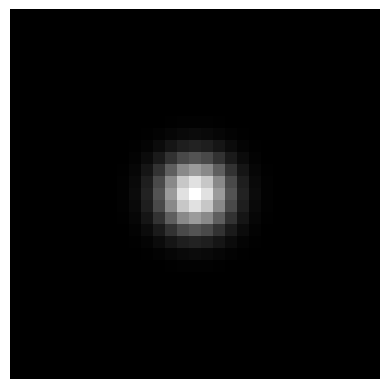

In [5]:
plt.imshow(psf.squeeze().detach().cpu().numpy(), cmap="gray")
plt.axis('off')

In [14]:
import torch
import torch.nn.functional as F

def learnable_multispot_psf(K, offsets, log_sigma, device="cpu", dtype=torch.float32, eps=1e-12):
    """
    Learnable multi-spot PSF with *very few* parameters:
      - fixed spot positions (offsets)
      - all spots have equal weight (no per-spot amplitudes)
      - learn only sigma (spot width), via log_sigma -> softplus(log_sigma)

    K: odd int, PSF size (K,K)
    offsets: list of (dx, dy) spot offsets relative to center, in pixels (ints or floats)
    log_sigma: scalar torch Parameter (unconstrained)
    returns: psf (K,K) nonnegative, sum=1
    """
    assert K % 2 == 1
    c = K // 2

    # make offsets a tensor on the right device
    off = torch.tensor(offsets, device=device, dtype=dtype)  # (S,2)
    S = off.shape[0]

    sigma = F.softplus(log_sigma) + 1e-8

    ax = torch.arange(K, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ax, ax, indexing="ij")          # (K,K)

    x0 = c + off[:, 0]  # (S,)
    y0 = c + off[:, 1]  # (S,)

    dx = xx[None, :, :] - x0[:, None, None]  # (S,K,K)
    dy = yy[None, :, :] - y0[:, None, None]  # (S,K,K)

    spots = torch.exp(-(dx*dx + dy*dy) / (2 * sigma * sigma))  # (S,K,K)

    psf = spots.mean(dim=0)          # equal amplification across spots
    psf = psf / (psf.sum() + eps)    # sum to 1
    return psf

# ---- example usage ----
K = 31

# fixed spot positions: 5-spot plus pattern
offsets = [(0,0), (6,0), (-6,0), (0,6), (0,-6)]

log_sigma = torch.nn.Parameter(torch.tensor(0.5))  # learnable scalar

psf = learnable_multispot_psf(K, offsets, log_sigma)
psf_4d = psf[None, None, :, :]  # (1,1,K,K) for conv2d

print("psf sum:", float(psf.sum()))
print("sigma:", float(torch.nn.functional.softplus(log_sigma)))


psf sum: 1.0
sigma: 0.9740769863128662


(np.float64(-0.5), np.float64(30.5), np.float64(30.5), np.float64(-0.5))

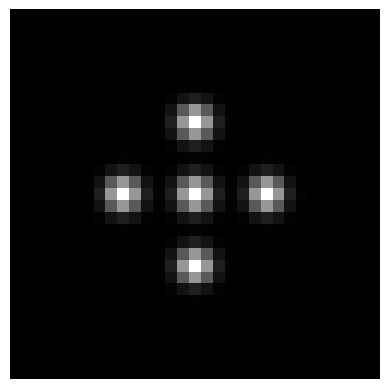

In [15]:
plt.imshow(psf.squeeze().detach().cpu().numpy(), cmap="gray")
plt.axis('off')

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LearnableCountMultiSpotPSF(nn.Module):
    """
    - Candidate spot locations are fixed (offsets).
    - Learn which candidates are "on" via gates in [0,1].
    - All active spots have equal amplification because we normalize gates to sum to 1.
    - Also learns a single shared sigma (spot width).
    """
    def __init__(self, K, offsets, sigma_init=0.0, gate_init=0.0, device="cpu"):
        super().__init__()
        assert K % 2 == 1
        self.K = K
        self.device = device

        # (S,2) candidate offsets (dx, dy)
        self.register_buffer("offsets", torch.tensor(offsets, dtype=torch.float32, device=device))

        # learnable scalar spot width
        self.log_sigma = nn.Parameter(torch.tensor(float(sigma_init), device=device))

        # learnable gate logits for each candidate spot (S,)
        # sigmoid(logits) -> gate in (0,1)
        S = len(offsets)
        self.gate_logits = nn.Parameter(torch.full((S,), float(gate_init), device=device))

    def forward(self, eps=1e-12):
        K = self.K
        c = K // 2

        sigma = F.softplus(self.log_sigma) + 1e-8  # >0
        gates = torch.sigmoid(self.gate_logits)    # (S,) in (0,1)

        # normalize so total weight across spots sums to 1 (equal-ish among active)
        w = gates / (gates.sum() + eps)            # (S,)

        ax = torch.arange(K, device=self.offsets.device, dtype=torch.float32)
        yy, xx = torch.meshgrid(ax, ax, indexing="ij")  # (K,K)

        x0 = c + self.offsets[:, 0]  # (S,)
        y0 = c + self.offsets[:, 1]  # (S,)

        dx = xx[None, :, :] - x0[:, None, None]  # (S,K,K)
        dy = yy[None, :, :] - y0[:, None, None]  # (S,K,K)

        spots = torch.exp(-(dx*dx + dy*dy) / (2.0 * sigma * sigma))  # (S,K,K)

        psf = (w[:, None, None] * spots).sum(dim=0)  # (K,K), nonnegative
        psf = psf / (psf.sum() + eps)                # sum=1
        return psf

    def effective_num_spots(self):
        # continuous proxy for "how many are on"
        return torch.sigmoid(self.gate_logits).sum()


psf shape: torch.Size([31, 31])
psf sum: 1.0000001192092896
effective #spots: 4.5
grad log_sigma: True
grad gate_logits: True


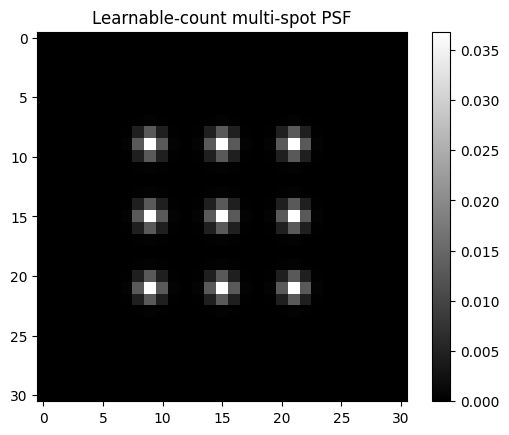

In [17]:
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

K = 31
offsets = [(0,0), (6,0), (-6,0), (0,6), (0,-6), (6,6), (-6,6), (6,-6), (-6,-6)]

psf_mod = LearnableCountMultiSpotPSF(K, offsets, sigma_init=0.0, gate_init=0.0, device=device).to(device)

psf = psf_mod()
print("psf shape:", psf.shape)
print("psf sum:", float(psf.sum()))
print("effective #spots:", float(psf_mod.effective_num_spots()))

# gradient check
loss = (psf**2).sum()
loss.backward()
print("grad log_sigma:", psf_mod.log_sigma.grad is not None)
print("grad gate_logits:", psf_mod.gate_logits.grad is not None)

plt.imshow(psf.detach().cpu().numpy(), cmap="gray")
plt.colorbar()
plt.title("Learnable-count multi-spot PSF")
plt.show()
